In [2]:
import math
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


In [3]:
df = pd.read_csv('preprocessing-1.csv')
df['crash_date'] = pd.to_datetime(df['crash_date'])

In [4]:
print(df.nunique())

crash_date              1165
city                       2
district                  12
zone                      41
crash_occurred_on          6
type_of_roadway            5
road_surface              11
weather_condition          9
lighting_condition         8
injury                     2
fatality                   2
hit_and_run                2
pedestrian_involved        2
train_involved             2
intersection               2
total_vehicles             9
vehicle_alignment          4
relation_to_roadway       11
manner_of_collision        8
primary_factor            12
secondary_factor          13
latitude               42308
longitude              42334
day_of_week                7
crash_month               12
dtype: int64


In [5]:
def countplot(df: pd.DataFrame, columns: list, grid_cols: int=2, palette: str='viridis'):
    """
    Creates a grid of count plots for the specified categorical columns.

    Args:
        df (pd.DataFrame): The DataFrame containing the data.
        columns (list): A list of column names to plot.
        grid_cols (int): The number of columns in the subplot grid.
    """
    num_plots = len(columns)
    grid_rows = math.ceil(num_plots/grid_cols)

    fig, axes = plt.subplots(
        nrows=grid_rows,
        ncols=grid_cols,
        figsize=(grid_cols*7, grid_rows*7)
    )
    
    axes = axes.flatten() # Axes is 2D, flattening it to 1D
    
    for i, col in enumerate(columns):
        ax = axes[i]
        sns.countplot(
            data=df,
            y=col,
            order=df[col].value_counts().index,
            ax=ax,
            palette=palette
        )

        ax.set_title(f'Distribution of {' '.join(col.split('_')).title()}', fontsize=12)
        ax.set_xlabel('Count')
        ax.set_ylabel('')

    # Turn all the axes that haven't been used
    for i in range(num_plots, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()

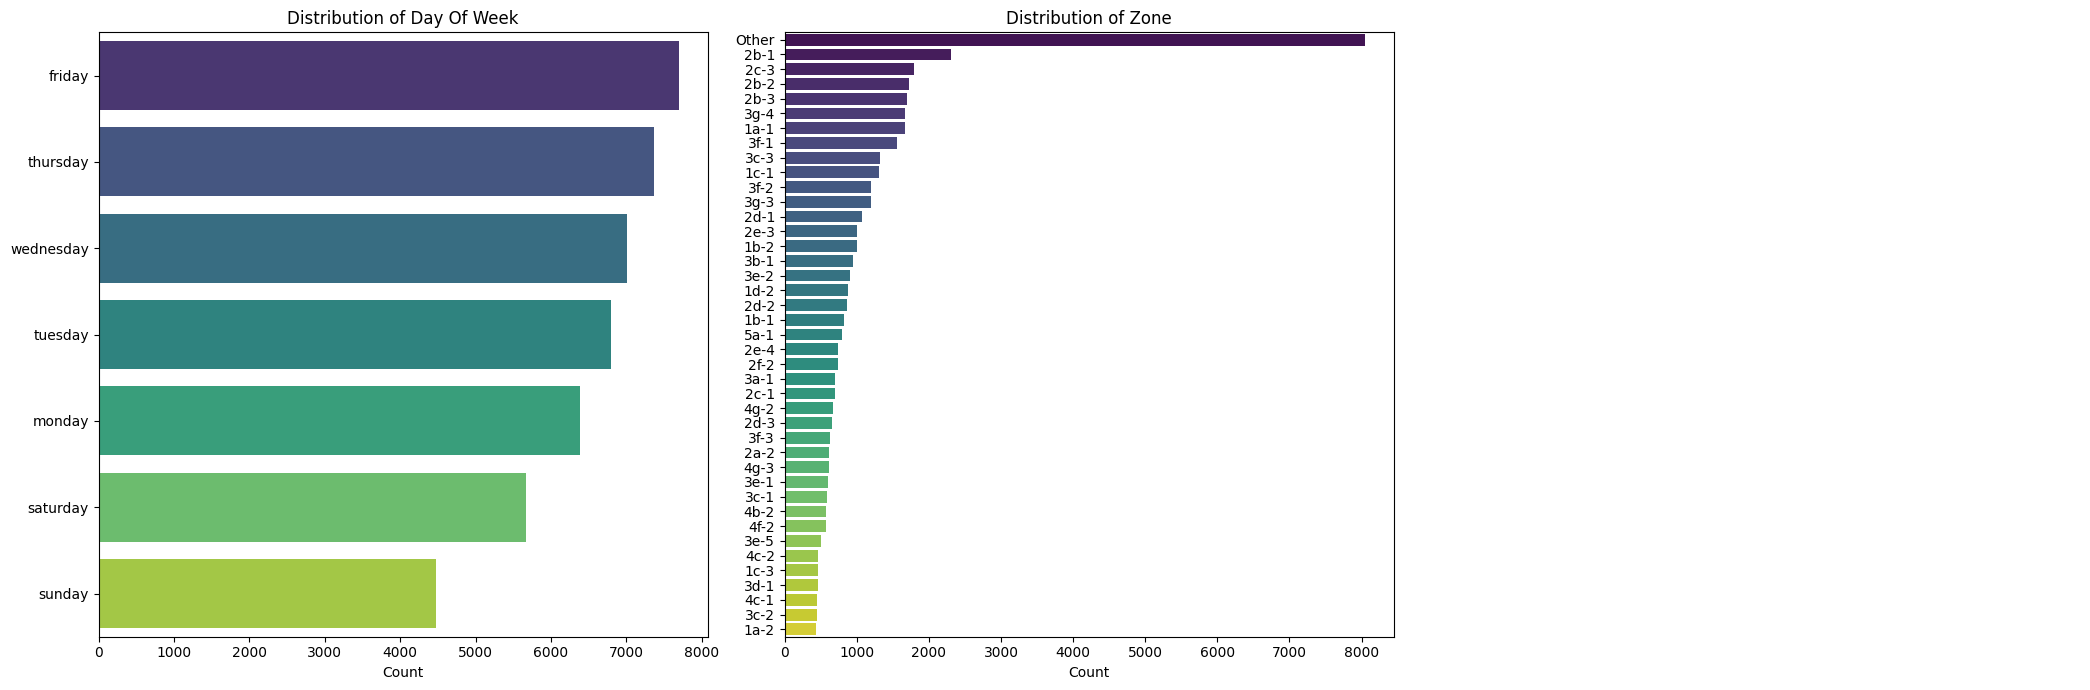

In [60]:
countplot_cols = ['day_of_week', 'zone']
countplot(df=df, columns=countplot_cols, grid_cols=3)

In [7]:
df['crash_year'] = df['crash_date'].dt.year

In [8]:
monthly_counts = df.groupby(['crash_year', 'crash_month']).size().reset_index(name='count')

# Get the list of unique years
unique_years = sorted(monthly_counts['crash_year'].unique())
num_years = len(unique_years)

# Define the grid layout (e.g., 3 columns per row)
grid_cols = 3
grid_rows = math.ceil(num_years / grid_cols)

# Create an empty figure with a grid of subplots
fig = make_subplots(
    rows=grid_rows,
    cols=grid_cols,
    subplot_titles=[str(y) for y in unique_years] # Use years as subplot titles
)

# --- 2. Loop and Add Traces ---
for i, year in enumerate(unique_years):
    # Calculate the row and column for the current subplot (1-indexed)
    row = (i // grid_cols) + 1
    col = (i % grid_cols) + 1
    
    # Filter data for the current year
    df_year = monthly_counts[monthly_counts['crash_year'] == year]
    
    # Add a line trace to the appropriate subplot
    fig.add_trace(
        go.Scatter(
            x=df_year['crash_month'],
            y=df_year['count'],
            mode='lines+markers',
            name=str(year)
        ),
        row=row,
        col=col
    )

# --- 3. Customize Layout ---
fig.update_layout(
    title_text='Monthly Crash Counts by Year',
    height=500,
    width=1200,
    showlegend=False # Hide the legend as subplot titles are sufficient
)

# Update all x-axes to show month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
fig.update_xaxes(
    # title_text='Month',
    tickmode='array',
    tickvals=list(range(1, 13)),
    ticktext=month_names
)

# Update all y-axes to have a title
fig.update_yaxes(title_text='Number of Crashes')
fig.show()

In [9]:
# Get the counts for each collision type
collision_counts = df['manner_of_collision'].value_counts()

fig = px.pie(
    names=collision_counts.index,
    values=collision_counts.values,
    title='Proportion of Collision Types',
    hole=0.3 # Creates a donut chart, which is often easier to look at
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(showlegend=False) # Hide legend if labels are inside
fig.show()

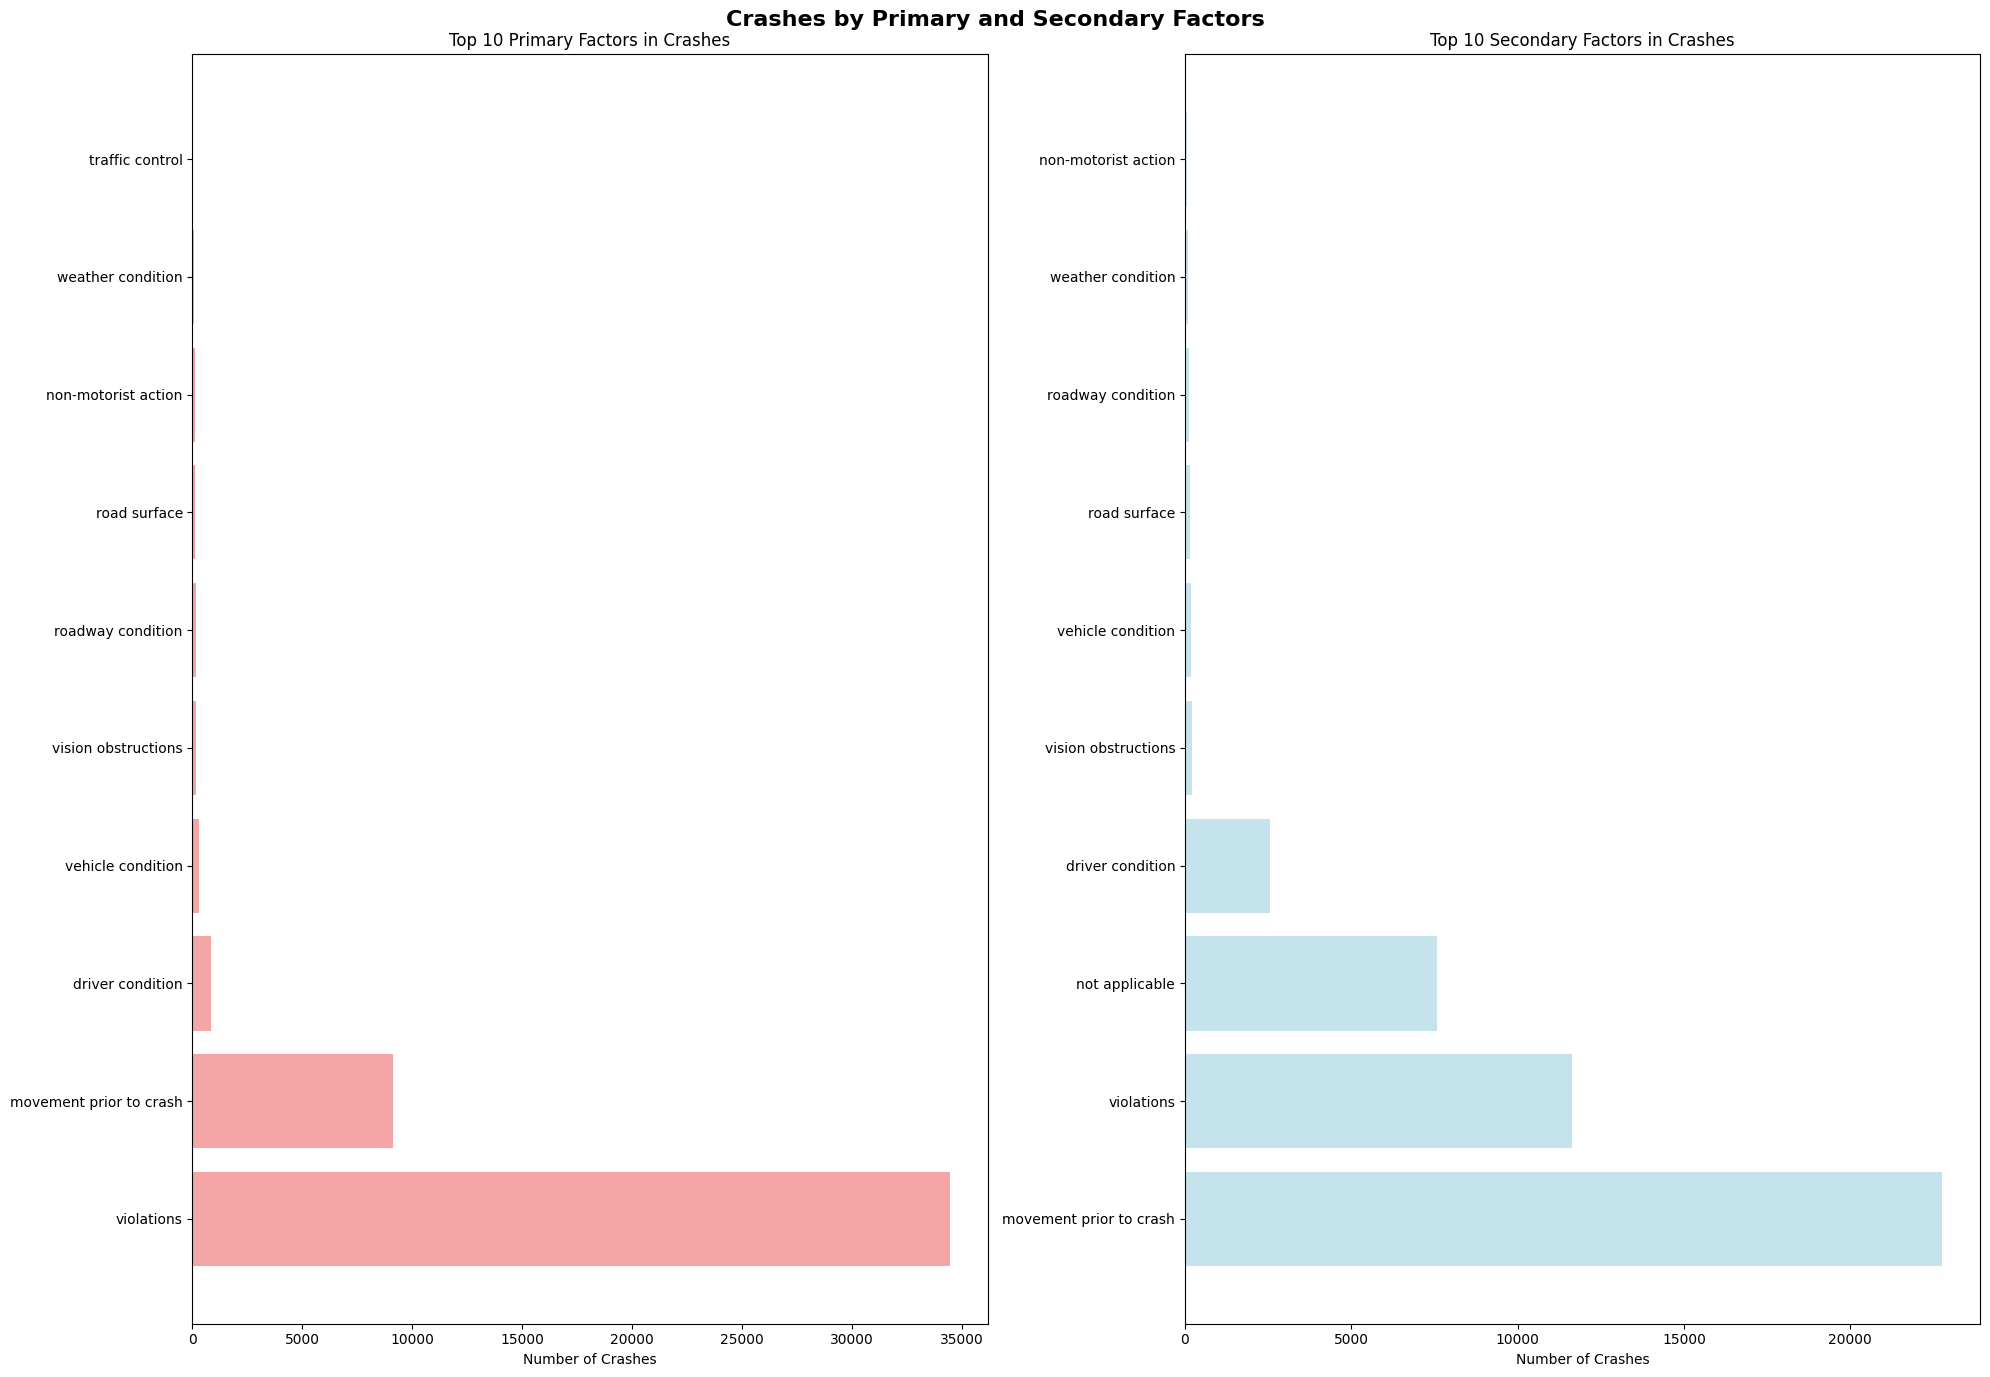

Most common primary factor: violations (34,450 crashes)
Most common secondary factor: movement prior to crash (22,763 crashes)


In [10]:
ig, axes = plt.subplots(1, 2, figsize=(20, 14))
ig.suptitle('Crashes by Primary and Secondary Factors', fontsize=16, fontweight='bold')

# 1. Primary Factors causing crashes
primary_factors = df['primary_factor'].value_counts().head(10)
axes[0].barh(range(len(primary_factors)), primary_factors.values, color='lightcoral', alpha=0.7)
axes[0].set_title('Top 10 Primary Factors in Crashes')
axes[0].set_xlabel('Number of Crashes')
axes[0].set_yticks(range(len(primary_factors)))
axes[0].set_yticklabels([factor[:30] + '...' if len(factor) > 30 else factor for factor in primary_factors.index])

# 2. Secondary Factors
secondary_factors = df['secondary_factor'].value_counts().head(10)
axes[1].barh(range(len(secondary_factors)), secondary_factors.values, color='lightblue', alpha=0.7)
axes[1].set_title('Top 10 Secondary Factors in Crashes')
axes[1].set_xlabel('Number of Crashes')
axes[1].set_yticks(range(len(secondary_factors)))
axes[1].set_yticklabels([factor[:30] + '...' if len(factor) > 30 else factor for factor in secondary_factors.index])

plt.tight_layout()
plt.show()
print(f"Most common primary factor: {primary_factors.index[0]} ({primary_factors.iloc[0]:,} crashes)")
print(f"Most common secondary factor: {secondary_factors.index[0]} ({secondary_factors.iloc[0]:,} crashes)")



In [11]:
collision_factors = pd.crosstab(df['manner_of_collision'], df['primary_factor'])

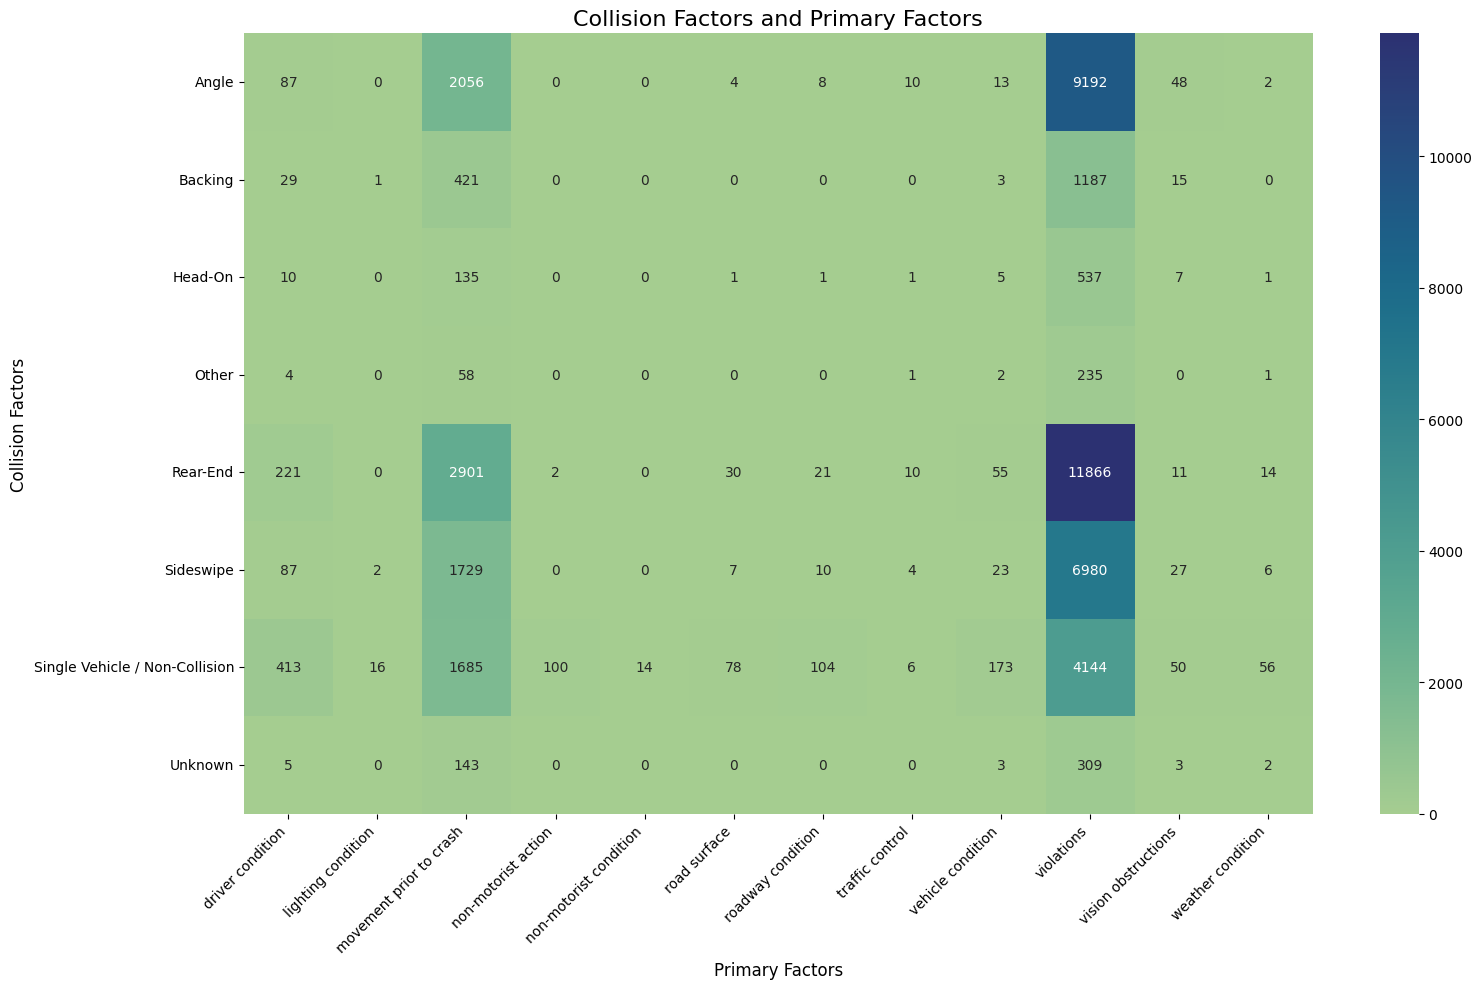

In [13]:
plt.figure(figsize=(16, 10))
sns.heatmap(collision_factors, annot=True, cmap='crest', fmt='d', cbar=True)
plt.title('Collision Factors and Primary Factors', fontsize=16)
plt.xlabel('Primary Factors', fontsize=12)
plt.ylabel('Collision Factors', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



In [15]:
df.columns

Index(['crash_date', 'city', 'district', 'zone', 'crash_occurred_on',
       'type_of_roadway', 'road_surface', 'weather_condition',
       'lighting_condition', 'injury', 'fatality', 'hit_and_run',
       'pedestrian_involved', 'train_involved', 'intersection',
       'total_vehicles', 'vehicle_alignment', 'relation_to_roadway',
       'manner_of_collision', 'primary_factor', 'secondary_factor', 'latitude',
       'longitude', 'day_of_week', 'crash_month', 'crash_year'],
      dtype='object')

In [50]:
df['relation_to_roadway'].value_counts()

relation_to_roadway
on roadway                       37171
in parking lane or zone           2421
off roadway, location unknown     1940
roadside                          1652
unknown                           1032
on shoulder, right side            290
median                             260
outside road/right-of-way          224
gore                               182
on shoulder, left side             115
separator/traffic island            98
Name: count, dtype: int64

In [69]:
def histogram(df: pd.DataFrame, columns: list, grid_cols: int=2):
    """
    Creates a grid of histograms for the specified numerical columns.

    Args:
        df (pd.DataFrame): The DataFrame containing the data.
        columns (list): A list of column names to plot.
        grid_cols (int): The number of columns in the subplot grid.
    """
    num_plots = len(columns)
    grid_rows = math.ceil(num_plots/grid_cols)

    fig, axes = plt.subplots(
        nrows=grid_rows,
        ncols=grid_cols,
        figsize=(grid_cols*5, grid_rows*5)
    )
    
    axes = axes.flatten() # Axes is 2D, flattening it to 1D
    
    for i, col in enumerate(columns):
        ax = axes[i]
        sns.histplot(
            data=df,
            x=col,
            bins=df[col].max(),
            # kde=True,
            ax=ax
        )

        ax.set_title(f'Distribution of {' '.join(col.split('_')).title()}', fontsize=12)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel('Number of Crashes')

    # Turn all the axes that haven't been used
    for i in range(num_plots, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()

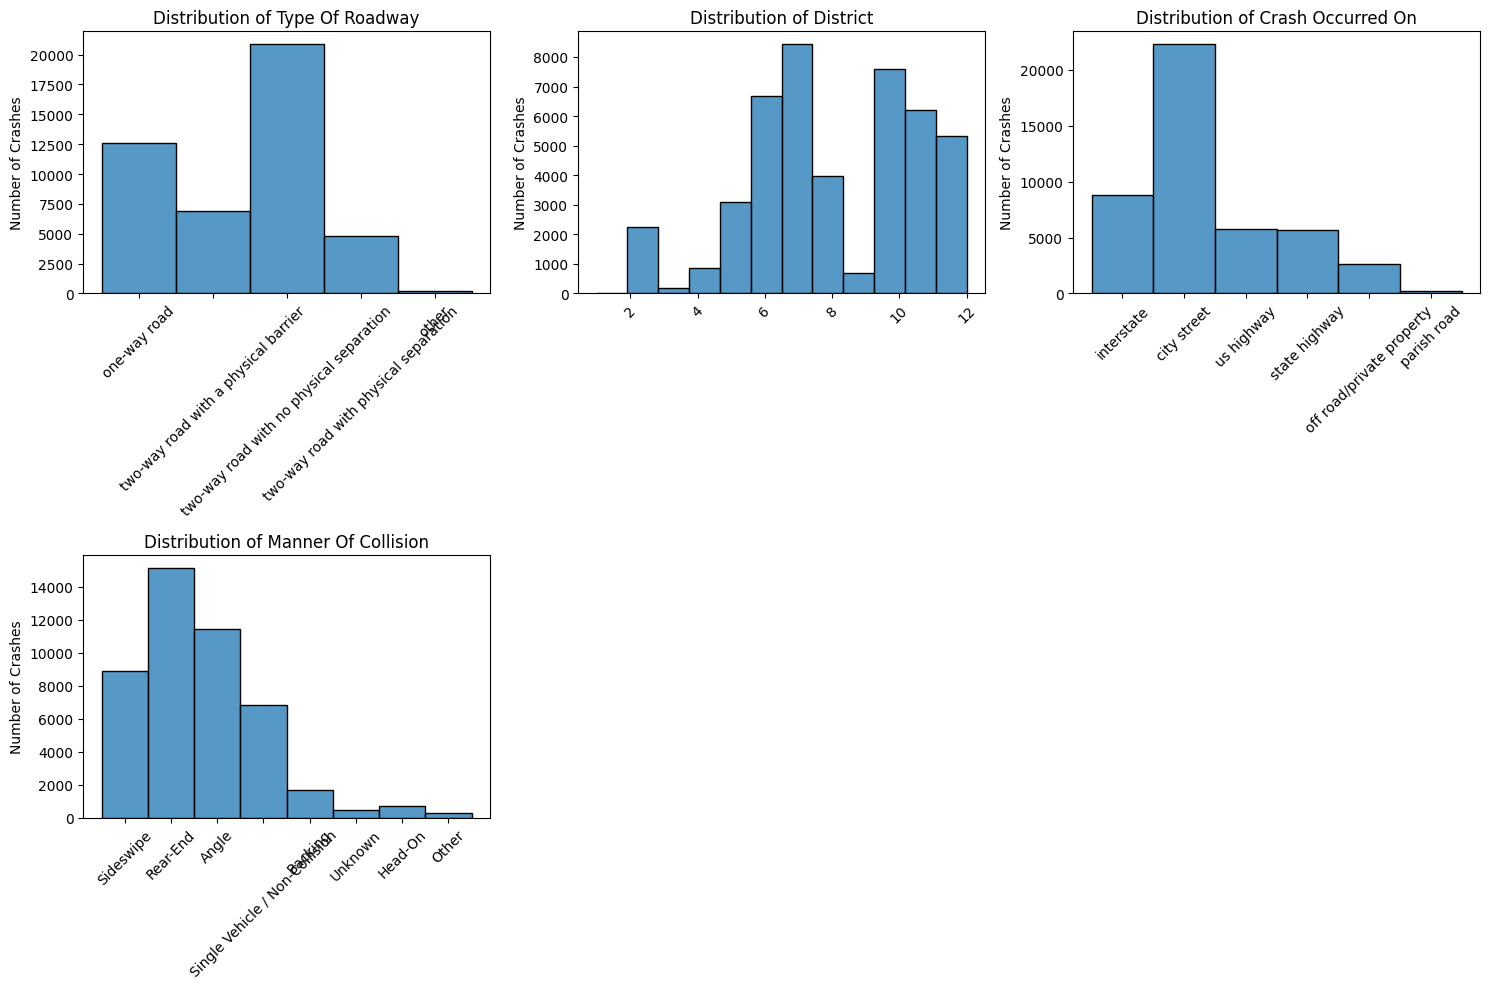

In [70]:
hist_cols = ['type_of_roadway', 'district', 'crash_occurred_on', 'manner_of_collision']
histogram(df=df, columns=hist_cols, grid_cols=3)

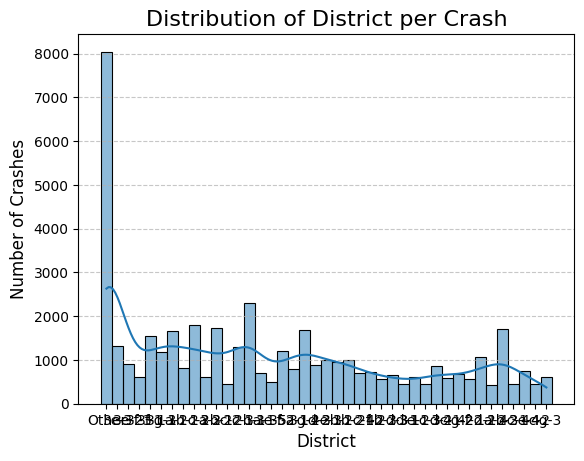

In [ ]:
sns.histplot(
    data=df,
    x='district',
    bins=df['district'].max(),
    kde=True
)

plt.title('Distribution of District per Crash', fontsize=16)
plt.xlabel('District', fontsize=12)
plt.ylabel('Number of Crashes', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()